In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [48]:
rawDF = pd.read_csv("gym_membership.csv")
rawDF.head()

,id,gender,birthday,Age,abonoment_type,visit_per_week,days_per_week,attend_group_lesson,fav_group_lesson,avg_time_check_in,avg_time_check_out,avg_time_in_gym,drink_abo,fav_drink,personal_training,name_personal_trainer,uses_sauna
0,1,Female,1997-04-18,27,Premium,4,"Mon, Sat, Tue, Wed",True,"Kickboxen, BodyPump, Zumba",19:31:00,21:27:00,116,False,NaN,False,NaN,True
1,2,Female,1977-09-18,47,Standard,3,"Mon, Sat, Wed",False,NaN,19:31:00,20:19:00,48,False,NaN,True,Chantal,False
2,3,Male,1983-03-30,41,Premium,1,Sat,True,XCore,08:29:00,10:32:00,123,True,"berry_boost, lemon",True,Mike,False
3,4,Male,1980-04-12,44,Premium,3,"Sat, Tue, Wed",False,NaN,09:54:00,11:33:00,99,True,passion_fruit,True,Mike,True
4,5,Male,1980-09-10,44,Standard,2,"Thu, Wed",True,"Running, Yoga, Zumba",08:29:00,09:19:00,50,False,NaN,True,Mike,False


In [49]:
rawDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   id                     1000 non-null   int64
 1   gender                 1000 non-null   str  
 2   birthday               1000 non-null   str  
 3   Age                    1000 non-null   int64
 4   abonoment_type         1000 non-null   str  
 5   visit_per_week         1000 non-null   int64
 6   days_per_week          1000 non-null   str  
 7   attend_group_lesson    1000 non-null   bool 
 8   fav_group_lesson       503 non-null    str  
 9   avg_time_check_in      1000 non-null   str  
 10  avg_time_check_out     1000 non-null   str  
 11  avg_time_in_gym        1000 non-null   int64
 12  drink_abo              1000 non-null   bool 
 13  fav_drink              496 non-null    str  
 14  personal_training      1000 non-null   bool 
 15  name_personal_trainer  518 non-null    str  
 16  

As we can see above. The dataset contains 1000 gym members and 17 variables describing their gym behavior, such as visits per week, subscription type, personal training usage, and sauna usage.

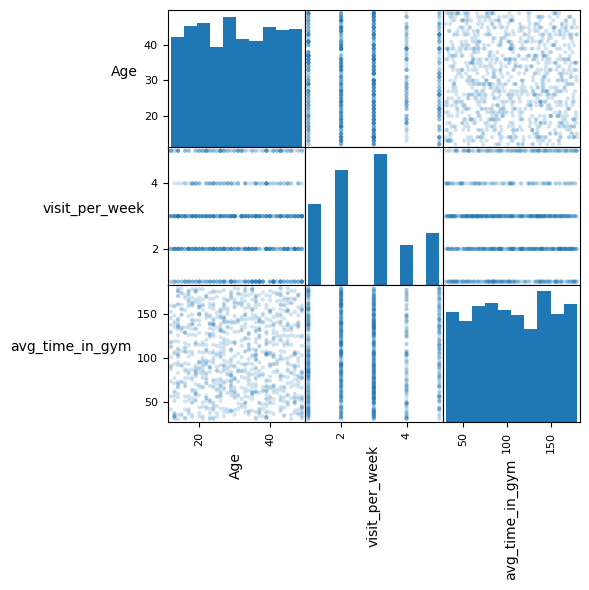

In [50]:
selDF = rawDF[['Age','visit_per_week','avg_time_in_gym']]

fig = scatter_matrix(selDF, alpha=0.2, figsize=(6,6), diagonal="hist")
for ax in fig.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha("right")

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

Making this scatter plot helps us to visually inspect possible relationship between: age, weekly visits, and time spent in the gym.

The variables id and birthday do not contain useful predictive information, so we remove them from the dataset.

In [51]:
cleanDF = rawDF.drop(["id","birthday","name_personal_trainer"], axis=1)
cleanDF.head()

,gender,Age,abonoment_type,visit_per_week,days_per_week,attend_group_lesson,fav_group_lesson,avg_time_check_in,avg_time_check_out,avg_time_in_gym,drink_abo,fav_drink,personal_training,uses_sauna
0,Female,27,Premium,4,"Mon, Sat, Tue, Wed",True,"Kickboxen, BodyPump, Zumba",19:31:00,21:27:00,116,False,NaN,False,True
1,Female,47,Standard,3,"Mon, Sat, Wed",False,NaN,19:31:00,20:19:00,48,False,NaN,True,False
2,Male,41,Premium,1,Sat,True,XCore,08:29:00,10:32:00,123,True,"berry_boost, lemon",True,False
3,Male,44,Premium,3,"Sat, Tue, Wed",False,NaN,09:54:00,11:33:00,99,True,passion_fruit,True,True
4,Male,44,Standard,2,"Thu, Wed",True,"Running, Yoga, Zumba",08:29:00,09:19:00,50,False,NaN,True,False


In [52]:
cntPT = cleanDF["personal_training"].value_counts()

propPT = cleanDF["personal_training"].value_counts(normalize=True)

cntPT
propPT

personal_training
True     0.518
False    0.482
Name: proportion, dtype: float64

The dataset is relatively balanced. About 51.8% of the members use personal training, while 48.2% do not. Because the classes are balanced, the model has no class imbalance, which makes evaluation reliable.

In [53]:
cleanDF[["Age","visit_per_week","avg_time_in_gym"]].describe()

,Age,visit_per_week,avg_time_in_gym
count,1000.000000,1000.000000,1000.000000
mean,30.604000,2.682000,105.260000
std,10.817958,1.241941,43.557177
min,12.000000,1.000000,30.000000
25%,21.000000,2.000000,67.000000
50%,30.000000,3.000000,104.000000
75%,40.000000,3.000000,143.000000
max,49.000000,5.000000,180.000000


The selected variables show different ranges of values. For example, age is measured in years while visit frequency is measured per week. Because kNN uses distance calculations, variables with larger ranges can have a larger influence on the model.

In [54]:
def normalize(x):
    return (x - min(x)) / (max(x) - min(x))

In [55]:
testSet1 = np.arange(1,6)
testSet2 = np.arange(1,6) * 10

print(f"testSet1: {testSet1}\n")
print(f"testSet2: {testSet2}\n")

print(f"Normalized testSet1: {normalize(testSet1)}\n")
print(f"Normalized testSet2: {normalize(testSet2)}\n")

testSet1: [1 2 3 4 5]

testSet2: [10 20 30 40 50]

Normalized testSet1: [0.   0.25 0.5  0.75 1.  ]

Normalized testSet2: [0.   0.25 0.5  0.75 1.  ]



The normalization function is between 0 and 1. this is important for kNN because of the distance it calculate. Without this lager ranges could imbalance the calculations.

In [56]:
excluded = ["personal_training"]

X = cleanDF.drop(excluded, axis=1)

#normalize only numeric columns (after errors used AI to help me with this)
#normalize function is trying to calculate with text columns. now we only
#normalize only numeric colums
num_cols = X.select_dtypes(include=["int64","float64"]).columns
X[num_cols] = X[num_cols].apply(normalize, axis=0)

In [57]:
#checking normalization

X[["Age","visit_per_week","avg_time_in_gym"]].describe()

,Age,visit_per_week,avg_time_in_gym
count,1000.000000,1000.000000,1000.000000
mean,0.502811,0.420500,0.501733
std,0.292377,0.310485,0.290381
min,0.000000,0.000000,0.000000
25%,0.243243,0.250000,0.246667
50%,0.486486,0.500000,0.493333
75%,0.756757,0.500000,0.753333
max,1.000000,1.000000,1.000000


In [58]:
excluded = ["personal_training"]

# Separate features
X = cleanDF.drop(excluded, axis=1)

# Convert categorical variables into numbers
X = pd.get_dummies(X, drop_first=True)

# Normalize numeric columns
num_cols = X.select_dtypes(include=["int64","float64"]).columns
X[num_cols] = X[num_cols].apply(normalize, axis=0)

# Label
y = cleanDF["personal_training"]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [60]:
# I had an error with 'Female output' and
#errors with 'Female output' this is because Knn uses numbers not string
#so above this code I will have to prep the data

knn = KNeighborsClassifier(n_neighbors=8)

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",8
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [61]:
y_pred = knn.predict(X_test)

In [62]:
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)

cm

array([[106,  40],
       [111,  43]])

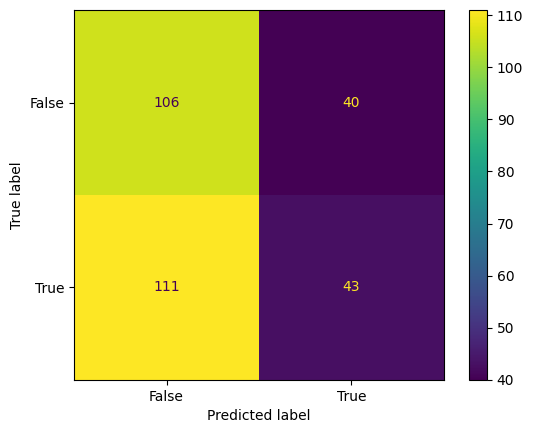

In [63]:
#show the array in a matrix for visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)

disp.plot()

plt.show()

Above we can see that:
106 correct predictions for non-personal training members

43 correct predictions for personal-training members

40 false positives

111 false negatives

The results are not very accurate, so let's try to make them more accurate.

Now we used a random K value. Let's find the best K value

In [64]:
#This calculates the accuracy for every k value between 1 and 21
accuracies = []

k_values = range(1,21)

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = np.mean(y_pred == y_test)

    accuracies.append(acc)

print(accuracies)

[np.float64(0.44333333333333336), np.float64(0.49), np.float64(0.5133333333333333), np.float64(0.52), np.float64(0.54), np.float64(0.5133333333333333), np.float64(0.5233333333333333), np.float64(0.49666666666666665), np.float64(0.5033333333333333), np.float64(0.48333333333333334), np.float64(0.52), np.float64(0.5366666666666666), np.float64(0.5066666666666667), np.float64(0.5366666666666666), np.float64(0.53), np.float64(0.5233333333333333), np.float64(0.5166666666666667), np.float64(0.5266666666666666), np.float64(0.51), np.float64(0.5166666666666667)]


It shows a lot of np.floats. Let's visualize it.

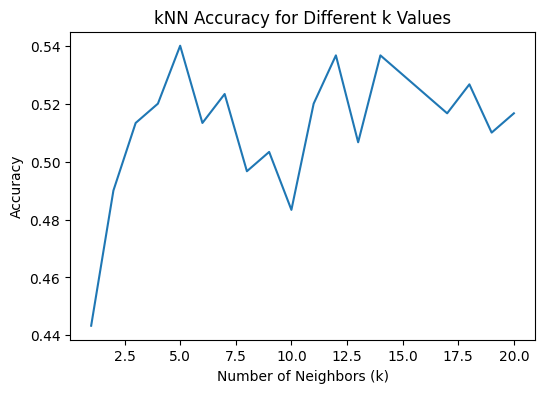

In [65]:
plt.figure(figsize=(6,4))

plt.plot(k_values, accuracies)

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")

plt.title("kNN Accuracy for Different k Values")

plt.show()

In [66]:
#select the best k value
best_k = k_values[np.argmax(accuracies)]

print("Best k:", best_k)

Best k: 5


Here I found out that I already had the best K value. Just for the sake of doing it, I continue with how I would continue if I changed the K value to a better one.

In [67]:
#now we select the best k value and make the confusion matrix after selecting the best k value
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

[[87 59]
 [79 75]]


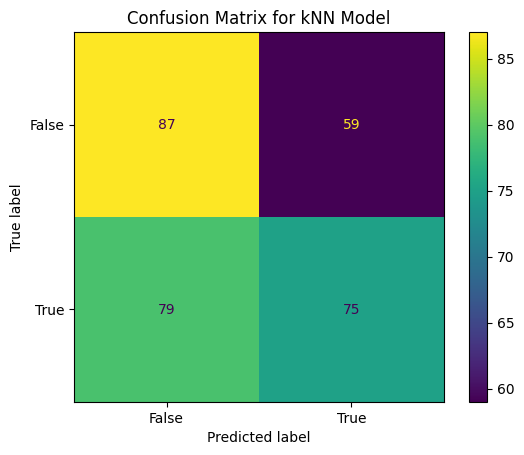

In [68]:
#show the value of the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
print(cm)
#make the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)

disp.plot()

plt.title("Confusion Matrix for kNN Model")

plt.show()

162 out of the 300 predictions were correct. This shows a 54% accuracy.